# Manufacturing Facilities Analysis - EPA ECHO Database

This notebook analyzes the number of permits in the EPA ECHO database that are for manufacturing facilities, using the NAICS code column.

Manufacturing NAICS codes:
- **31**: Food Manufacturing
- **32**: Manufacturing (includes wood, paper, chemical, plastics, etc.)
- **33**: Manufacturing (includes primary metals, machinery, electronics, etc.)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from permit_data_extraction.config import EXTERNAL_DATA_DIR


In [6]:
# Load the permit data
csv_file = Path(EXTERNAL_DATA_DIR) / "permit-hub-report-2025-07-21T20_12_03.354Z.csv"

# Try different encodings to handle special characters
try:
    df = pd.read_csv(csv_file, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(csv_file, encoding='latin-1')
    except:
        df = pd.read_csv(csv_file, encoding='cp1252')

print(f"Total permits in dataset: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")


Total permits in dataset: 9,958

Columns: ['Permit Title', 'Permitting Authority', 'Region', 'Permit Action Title', 'Permit Type', 'NSR Permit Action', 'Title V Permit Action', 'Submission Category', 'Permit Number', 'Owner/Operator', 'Application Number', 'Expedited Review Requested', 'Application Completeness Date', 'Application Receipt Date', 'Final Permitting Authority Action Date', 'Public Notice Period Start Date', 'Public Notice Period End Date', 'Beginning Of EPA 45 Day Review Period', 'End Of EPA 45 Day Review Period', 'Petition Period Start Date', 'Petition Period End Date', 'Submittal Date', 'EPA Review Status', 'Date of EPA Review Complete', 'EPA PoC Name', 'EPA PoC Phone', 'EPA PoC Email', 'Facility Name', 'Permit State', 'BIA Code', 'NAICS code', 'Address 1', 'Address 2', 'Zip Code', 'Latitude', 'Longitude', 'Source Type', 'Facility Type', 'Owner/Operator.1', 'Mobile No Fixed Address', 'Offshore', 'Permitting Authority Facility', 'Mailing Address 1', 'Mailing Address 2', 

# Check the NAICS code column
print("NAICS code column info:")
print(f"Column name: 'NAICS code'")
print(f"Non-null count: {df['NAICS code'].notna().sum():,}")
print(f"Null count: {df['NAICS code'].isna().sum():,}")
print(f"\nSample NAICS codes:")
print(df['NAICS code'].value_counts().head(10))


In [7]:
# Convert NAICS code to string and clean it
df['NAICS_code_clean'] = df['NAICS code'].astype(str).str.strip()

# Filter out missing/empty NAICS codes
df_with_naics = df[df['NAICS_code_clean'].notna() & (df['NAICS_code_clean'] != 'nan') & (df['NAICS_code_clean'] != '')]

print(f"Permits with valid NAICS codes: {len(df_with_naics):,}")
print(f"Permits without NAICS codes: {len(df) - len(df_with_naics):,}")


Permits with valid NAICS codes: 4,400
Permits without NAICS codes: 5,558


In [8]:
# Extract first 2 digits of NAICS code to identify manufacturing sector
# Manufacturing codes start with 31, 32, or 33
df_with_naics['NAICS_2digit'] = df_with_naics['NAICS_code_clean'].str[:2]

# Filter for manufacturing facilities (NAICS codes starting with 31, 32, or 33)
manufacturing_mask = df_with_naics['NAICS_2digit'].isin(['31', '32', '33'])
manufacturing_df = df_with_naics[manufacturing_mask].copy()

print(f"Total manufacturing facilities: {len(manufacturing_df):,}")
print(f"Percentage of all permits: {len(manufacturing_df) / len(df) * 100:.2f}%")
print(f"Percentage of permits with NAICS codes: {len(manufacturing_df) / len(df_with_naics) * 100:.2f}%")


Total manufacturing facilities: 2,363
Percentage of all permits: 23.73%
Percentage of permits with NAICS codes: 53.70%


/tmp/ipykernel_58565/1688416979.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_naics['NAICS_2digit'] = df_with_naics['NAICS_code_clean'].str[:2]


In [9]:
# Breakdown by manufacturing sector
manufacturing_breakdown = manufacturing_df['NAICS_2digit'].value_counts().sort_index()

print("Manufacturing facilities by sector:")
print("\n31 - Food Manufacturing:", manufacturing_breakdown.get('31', 0))
print("32 - Manufacturing (Wood, Paper, Chemical, Plastics, etc.):", manufacturing_breakdown.get('32', 0))
print("33 - Manufacturing (Primary Metals, Machinery, Electronics, etc.):", manufacturing_breakdown.get('33', 0))

print("\nDetailed breakdown:")
print(manufacturing_breakdown)


Manufacturing facilities by sector:

31 - Food Manufacturing: 196
32 - Manufacturing (Wood, Paper, Chemical, Plastics, etc.): 1533
33 - Manufacturing (Primary Metals, Machinery, Electronics, etc.): 634

Detailed breakdown:
NAICS_2digit
31     196
32    1533
33     634
Name: count, dtype: int64


In [10]:
# Top 20 NAICS codes for manufacturing facilities
top_naics = manufacturing_df['NAICS_code_clean'].value_counts().head(20)

print("Top 20 NAICS codes for manufacturing facilities:")
print(top_naics)


Top 20 NAICS codes for manufacturing facilities:
NAICS_code_clean
324110    180
321113    123
325199     69
322121     63
336612     62
327310     61
325180     56
322130     47
326140     46
325120     42
327420     40
331110     39
325211     38
324122     36
321999     35
326199     34
321212     30
327120     29
331492     27
321219     27
Name: count, dtype: int64


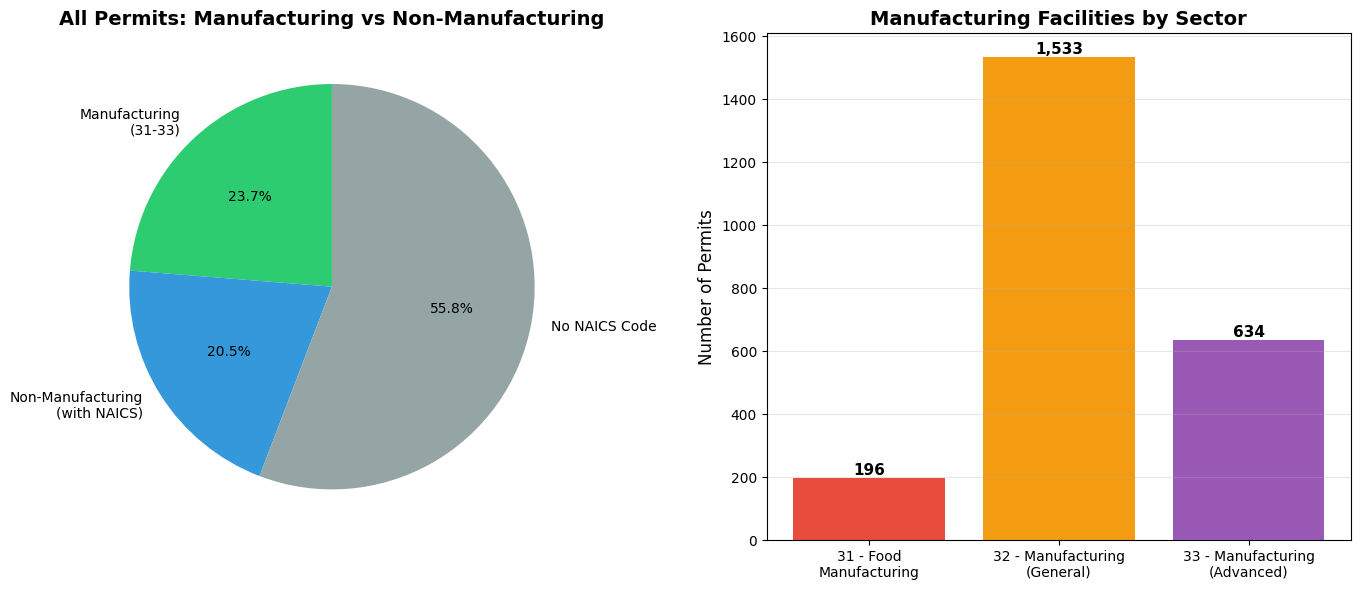

In [11]:
# Visualization: Manufacturing vs Non-Manufacturing
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart: Manufacturing vs Non-Manufacturing
all_permits = len(df)
with_naics = len(df_with_naics)
manufacturing = len(manufacturing_df)
non_manufacturing = with_naics - manufacturing
no_naics = all_permits - with_naics

labels = ['Manufacturing\n(31-33)', 'Non-Manufacturing\n(with NAICS)', 'No NAICS Code']
sizes = [manufacturing, non_manufacturing, no_naics]
colors = ['#2ecc71', '#3498db', '#95a5a6']

axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('All Permits: Manufacturing vs Non-Manufacturing', fontsize=14, fontweight='bold')

# Bar chart: Manufacturing by sector
sector_labels = ['31 - Food\nManufacturing', '32 - Manufacturing\n(General)', '33 - Manufacturing\n(Advanced)']
sector_counts = [
    manufacturing_breakdown.get('31', 0),
    manufacturing_breakdown.get('32', 0),
    manufacturing_breakdown.get('33', 0)
]

bars = axes[1].bar(sector_labels, sector_counts, color=['#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Manufacturing Facilities by Sector', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Permits', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


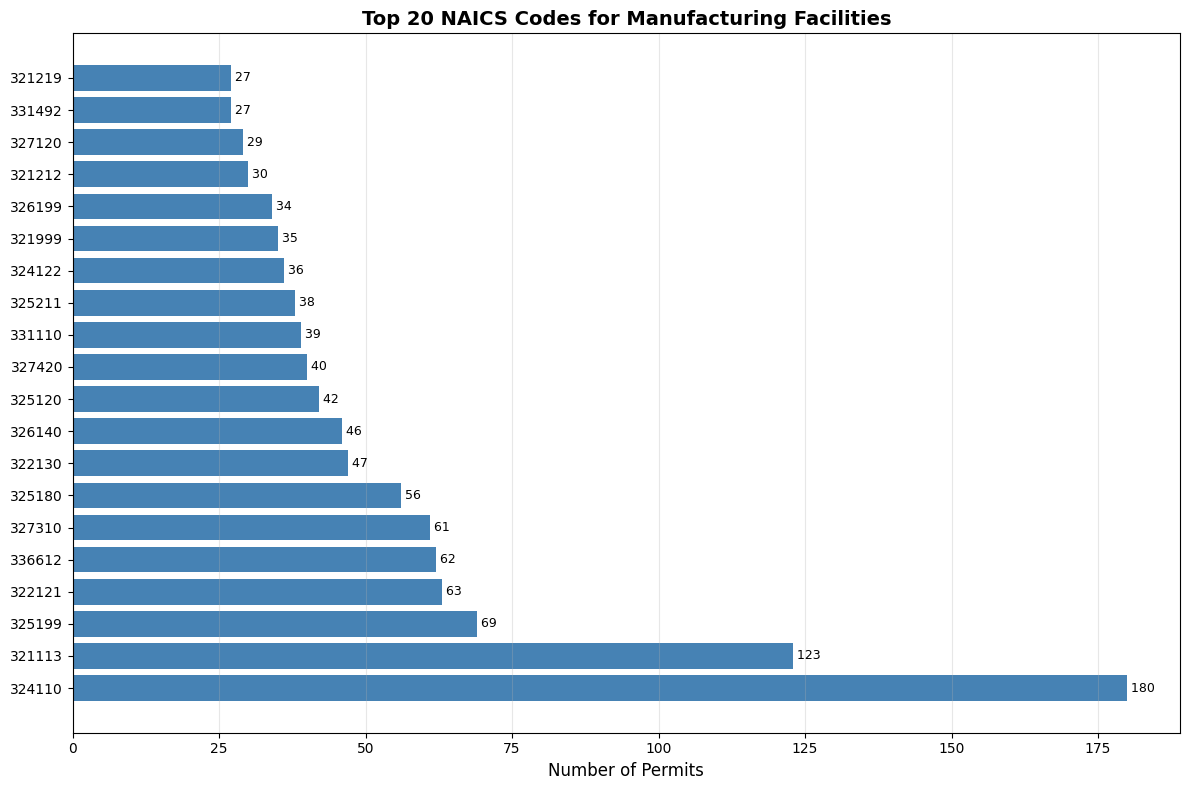

In [12]:
# Top 20 NAICS codes visualization
fig, ax = plt.subplots(figsize=(12, 8))

top_20_naics = manufacturing_df['NAICS_code_clean'].value_counts().head(20)
bars = ax.barh(range(len(top_20_naics)), top_20_naics.values, color='steelblue')
ax.set_yticks(range(len(top_20_naics)))
ax.set_yticklabels(top_20_naics.index, fontsize=10)
ax.set_xlabel('Number of Permits', fontsize=12)
ax.set_title('Top 20 NAICS Codes for Manufacturing Facilities', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(top_20_naics.items()):
    ax.text(val, i, f' {int(val):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


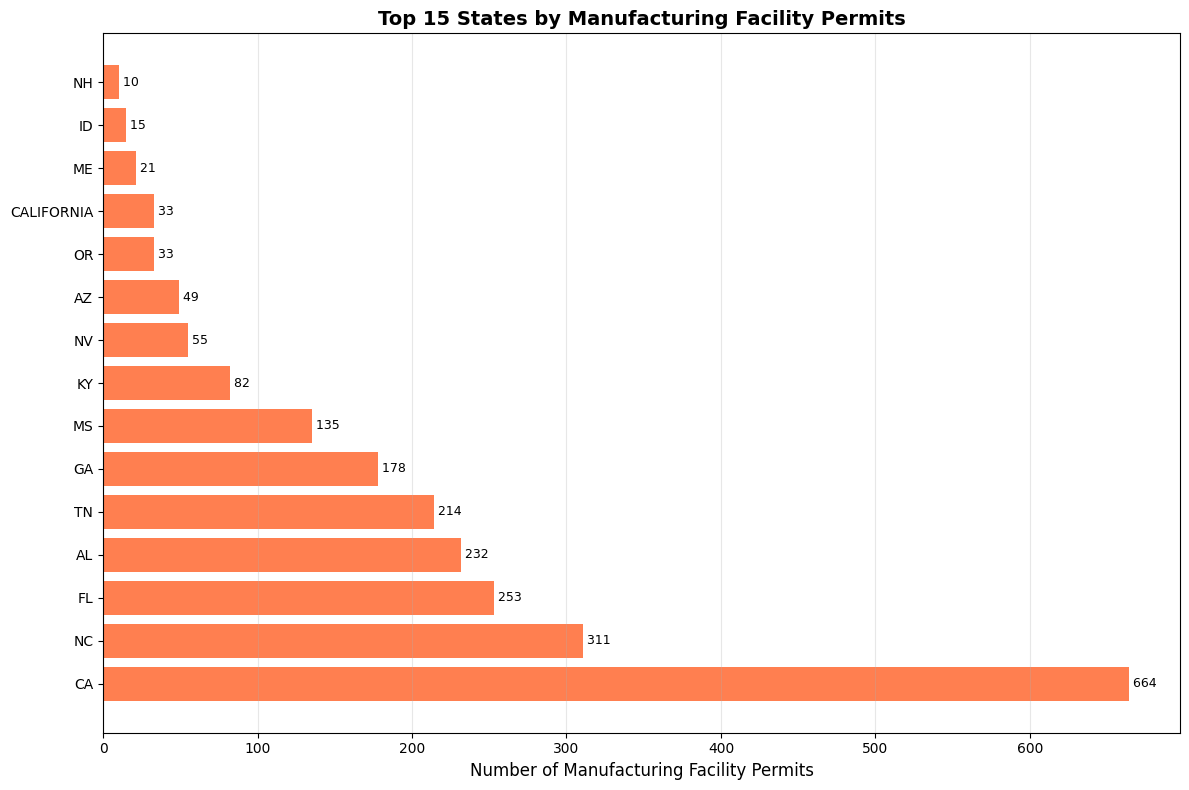


Top 15 states by manufacturing facility permits:
Permit State
CA            664
NC            311
FL            253
AL            232
TN            214
GA            178
MS            135
KY             82
NV             55
AZ             49
OR             33
CALIFORNIA     33
ME             21
ID             15
NH             10
Name: count, dtype: int64


In [13]:
# Manufacturing facilities by state
if 'Permit State' in manufacturing_df.columns:
    state_counts = manufacturing_df['Permit State'].value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(range(len(state_counts)), state_counts.values, color='coral')
    ax.set_yticks(range(len(state_counts)))
    ax.set_yticklabels(state_counts.index, fontsize=10)
    ax.set_xlabel('Number of Manufacturing Facility Permits', fontsize=12)
    ax.set_title('Top 15 States by Manufacturing Facility Permits', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (idx, val) in enumerate(state_counts.items()):
        ax.text(val, i, f' {int(val):,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 15 states by manufacturing facility permits:")
    print(state_counts)


In [14]:
# Summary statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"\nTotal permits in dataset: {len(df):,}")
print(f"Permits with NAICS codes: {len(df_with_naics):,} ({len(df_with_naics)/len(df)*100:.1f}%)")
print(f"Manufacturing facility permits: {len(manufacturing_df):,} ({len(manufacturing_df)/len(df)*100:.1f}% of all permits)")
print(f"Manufacturing as % of permits with NAICS: {len(manufacturing_df)/len(df_with_naics)*100:.1f}%")

print(f"\nManufacturing breakdown:")
print(f"  31 - Food Manufacturing: {manufacturing_breakdown.get('31', 0):,}")
print(f"  32 - Manufacturing (General): {manufacturing_breakdown.get('32', 0):,}")
print(f"  33 - Manufacturing (Advanced): {manufacturing_breakdown.get('33', 0):,}")

print(f"\nUnique manufacturing facilities (by Facility Name): {manufacturing_df['Facility Name'].nunique():,}")
print(f"Unique NAICS codes in manufacturing: {manufacturing_df['NAICS_code_clean'].nunique():,}")


SUMMARY STATISTICS

Total permits in dataset: 9,958
Permits with NAICS codes: 4,400 (44.2%)
Manufacturing facility permits: 2,363 (23.7% of all permits)
Manufacturing as % of permits with NAICS: 53.7%

Manufacturing breakdown:
  31 - Food Manufacturing: 196
  32 - Manufacturing (General): 1,533
  33 - Manufacturing (Advanced): 634

Unique manufacturing facilities (by Facility Name): 1,089
Unique NAICS codes in manufacturing: 254
